In [5]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import os

# =====================================================
# 1. VERİYİ YÜKLE
# =====================================================

print("Çalışılan dizin:", os.getcwd())

df = pl.read_parquet("data/processed/AEP_hourly_processed.parquet")

# Target kolonunu otomatik bul
ENGINEERED_COLS = {
    "Datetime","hour","dayofweek","month","year","is_weekend",
    "sin_hour","cos_hour",
    "target_lag_1","target_lag_24",
    "target_roll_mean_24","target_roll_std_24"
}

target_candidates = [
    c for c in df.columns
    if c not in ENGINEERED_COLS
]

target_col = target_candidates[0]
print("Target kolon:", target_col)

# Datetime tipi kontrol
if df["Datetime"].dtype != pl.Datetime:
    df = df.with_columns(
        pl.col("Datetime").str.to_datetime()
    )

df = df.sort("Datetime")
df_pd = df.to_pandas()


Çalışılan dizin: /app
Target kolon: AEP_MW


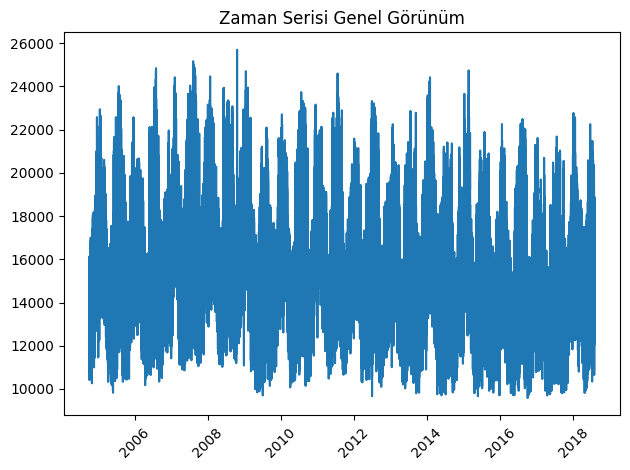

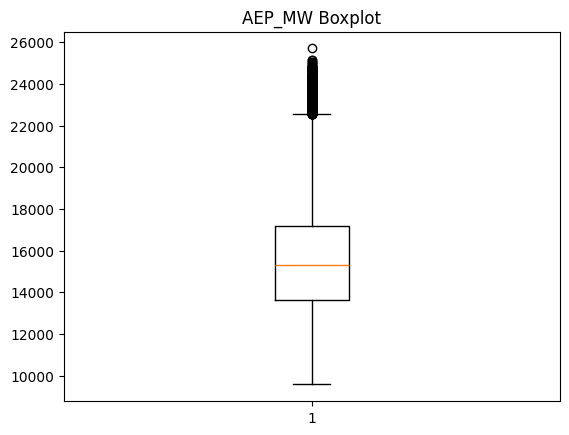

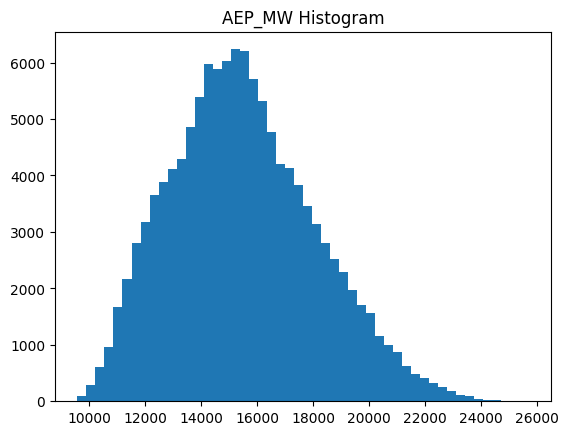

In [6]:

# =====================================================
# ANALİZ 1: ZAMAN SERİSİ
# =====================================================

plt.figure()
plt.plot(df_pd["Datetime"], df_pd[target_col])
plt.title("Zaman Serisi Genel Görünüm")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =====================================================
# ANALİZ 2: DAĞILIM
# =====================================================

plt.figure()
plt.boxplot(df_pd[target_col])
plt.title(f"{target_col} Boxplot")
plt.show()

plt.figure()
plt.hist(df_pd[target_col], bins=50)
plt.title(f"{target_col} Histogram")
plt.show()


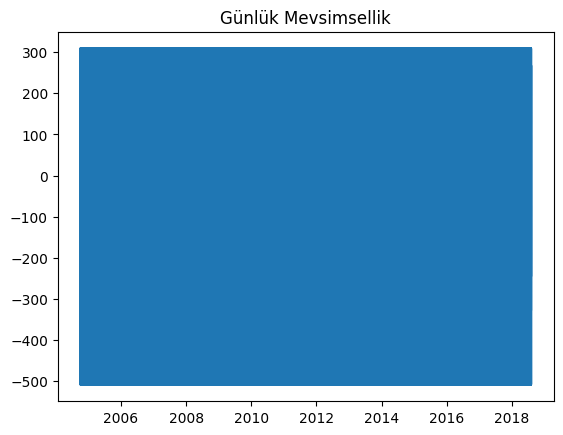

In [7]:

# =====================================================
# ANALİZ 3: MEVSİMSELLİK
# =====================================================

analysis_df = df_pd.set_index("Datetime")[target_col]

decomposition = seasonal_decompose(
    analysis_df,
    model='additive',
    period=24
)

plt.figure()
plt.plot(decomposition.seasonal)
plt.title("Günlük Mevsimsellik")
plt.show()


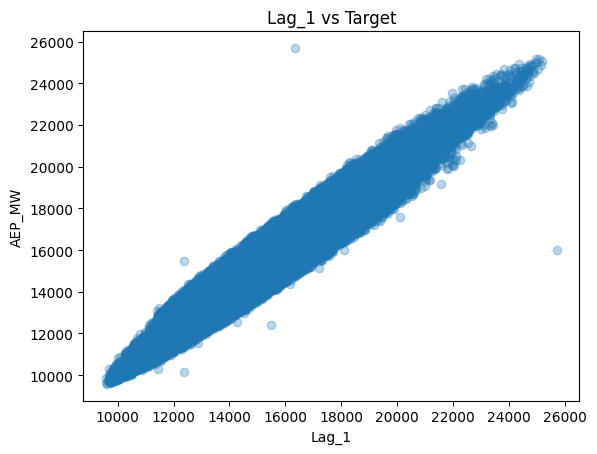

In [8]:
# =====================================================
# ANALİZ 4: LAG KORELASYON
# =====================================================

df_lag = df.with_columns(
    pl.col(target_col).shift(1).alias("lag_1")
).drop_nulls()

df_lag_pd = df_lag.to_pandas()

plt.figure()
plt.scatter(df_lag_pd["lag_1"], df_lag_pd[target_col], alpha=0.3)
plt.title("Lag_1 vs Target")
plt.xlabel("Lag_1")
plt.ylabel(target_col)
plt.show()

In [9]:
# =====================================================
# ANALİZ 5: OUTLIER (IQR)
# =====================================================

q1 = df[target_col].quantile(0.25)
q3 = df[target_col].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df.filter(
    (pl.col(target_col) < lower_bound) |
    (pl.col(target_col) > upper_bound)
)

print(f"Toplam Aykırı Değer Sayısı: {len(outliers)} "
      f"({len(outliers)/len(df)*100:.2f}%)")

Toplam Aykırı Değer Sayısı: 665 (0.55%)


In [10]:
df.shape

(121249, 13)